In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('ex2data1.txt', header=None, names=['Exam 1', 'Exam 2', 'Admitted'])
print(data.head())
print(data.describe())



      Exam 1     Exam 2  Admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1
           Exam 1      Exam 2    Admitted
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000


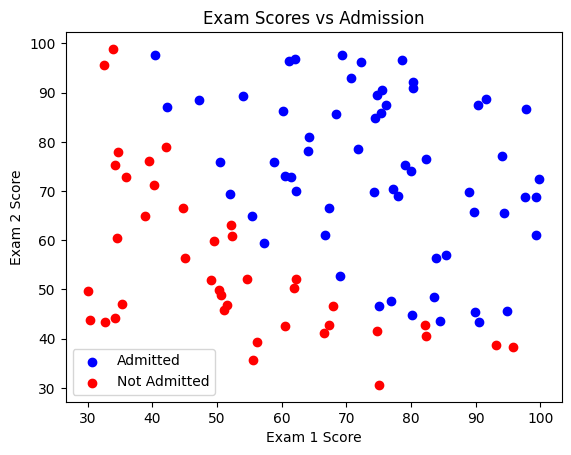

In [5]:
#Create a scatter plot to visualize the data points for students who were admitted versus those who were not based on their exam scores.
admitted = data[data['Admitted'] == 1]
not_admitted = data[data['Admitted'] == 0]
plt.scatter(admitted['Exam 1'], admitted['Exam 2'], color='blue', label='Admitted')
plt.scatter(not_admitted['Exam 1'], not_admitted['Exam 2'], color='red', label='Not Admitted')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Exam Scores vs Admission')
plt.legend()
plt.show()

In [6]:
#Applying Logistic Regression with scikit-learn:

# Implement logistic regression using the LogisticRegression function from scikit-learn to find the best parameters for your model.
# Train the logistic regression model on your dataset.
X = data[['Exam 1', 'Exam 2']]
y = data['Admitted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

#some helpful print statements to check the model's performance
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)
print("Training accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))


Model coefficients: [[0.25970232 0.22481016]]
Model intercept: [-30.20000099]
Training accuracy: 0.9125
Test accuracy: 0.8


In [7]:
# Making Predictions:

# Use the trained logistic regression model to make predictions on your dataset.
# Calculate the accuracy of your model.
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Prediction accuracy:", accuracy)


Prediction accuracy: 0.8


In [8]:
# Model Evaluation:

# Interpret the result of logistic regression and the accuracy of your model.
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"\nThe model achieved {accuracy:.2%} accuracy on the test set.")
print(f"Coefficients: Exam 1 → {model.coef_[0][0]:.4f}, Exam 2 → {model.coef_[0][1]:.4f}")
print(f"A positive coefficient means higher scores increase admission probability.")


Confusion Matrix:
[[7 1]
 [3 9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20


The model achieved 80.00% accuracy on the test set.
Coefficients: Exam 1 → 0.2597, Exam 2 → 0.2248
A positive coefficient means higher scores increase admission probability.


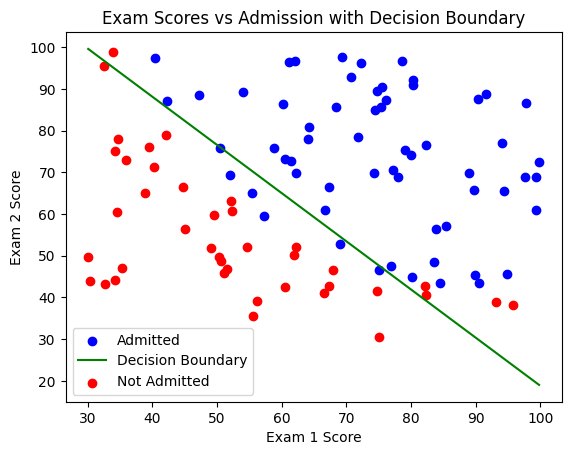

In [10]:
import numpy as np

x_boundary = np.linspace(data['Exam 1'].min(), data['Exam 1'].max(), 100)
y_boundary = -(model.intercept_[0] + model.coef_[0][0] * x_boundary) / model.coef_[0][1]
plt.scatter(admitted['Exam 1'], admitted['Exam 2'], color='blue', label='Admitted')
plt.plot(x_boundary, y_boundary, color='green', label='Decision Boundary')
plt.scatter(not_admitted['Exam 1'], not_admitted['Exam 2'], color='red', label='Not Admitted')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Exam Scores vs Admission with Decision Boundary')
plt.legend()